In [86]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [87]:
df = pd.read_csv(
    r"D:\Election Data Project\data\processed\Elections_Feature_Engineered.csv"
)

In [88]:
df.head()

,Country,country_type,election_year,election_date,largest_electorate,largest_winner,second_electorate,second_winner,third_electorate,third_winner,...,agreement_score,prediction_confidence,top3_sweep,regional_winner_diversity,election_decade,years_since_previous_election,country_total_elections,country_type_encoded,prediction_error_category,majority_winner_region_count
0,Brazil,Developing,1989,1989-11-15,SÆo Paulo,Fernando Collor,Minas Gerais,Fernando Collor,Rio de Janeiro,Fernando Collor,...,1.000000,Very High,True,1,1980,NaN,9,0,Correct Prediction,3
1,Brazil,Developing,1994,1994-10-03,SÆo Paulo,Fernando Henrique Cardoso,Minas Gerais,Fernando Henrique Cardoso,Rio de Janeiro,Fernando Henrique Cardoso,...,1.000000,Very High,True,1,1990,5.0,9,0,Correct Prediction,3
2,Brazil,Developing,1998,1998-10-04,SÆo Paulo,Fernando Henrique Cardoso,Minas Gerais,Fernando Henrique Cardoso,Rio de Janeiro,Fernando Henrique Cardoso,...,1.000000,Very High,True,1,1990,4.0,9,0,Correct Prediction,3
3,Brazil,Developing,2002,2002-10-27,SÆo Paulo,Jos‚ Serra,Minas Gerais,Lula,Rio de Janeiro,Lula,...,0.666667,Low,False,2,2000,4.0,9,0,Correct Prediction,2
4,Brazil,Developing,2006,2006-10-29,SÆo Paulo,Geraldo Alckmin,Minas Gerais,Lula,Rio de Janeiro,Lula,...,0.666667,Low,False,2,2000,4.0,9,0,Correct Prediction,2


In [89]:
df.shape

(57, 24)

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        57 non-null     object 
 1   country_type                   57 non-null     object 
 2   election_year                  57 non-null     int64  
 3   election_date                  57 non-null     object 
 4   largest_electorate             57 non-null     object 
 5   largest_winner                 57 non-null     object 
 6   second_electorate              57 non-null     object 
 7   second_winner                  57 non-null     object 
 8   third_electorate               57 non-null     object 
 9   third_winner                   57 non-null     object 
 10  national_winner                57 non-null     object 
 11  majority_winner                57 non-null     object 
 12  prediction_correct             57 non-null     bool 

In [91]:
df.describe()

,election_year,match_count,agreement_score,regional_winner_diversity,election_decade,years_since_previous_election,country_total_elections,country_type_encoded,majority_winner_region_count
count,57.000000,57.000000,57.000000,57.000000,57.000000,51.000000,57.000000,57.000000,57.000000
mean,2001.456140,2.333333,0.777778,1.491228,1997.017544,4.607843,10.649123,0.596491,2.508772
std,15.559873,0.763763,0.254588,0.504367,15.919991,0.634931,3.603031,0.494962,0.504367
min,1964.000000,0.000000,0.000000,1.000000,1960.000000,4.000000,5.000000,0.000000,2.000000
25%,1991.000000,2.000000,0.666667,1.000000,1990.000000,4.000000,9.000000,0.000000,2.000000
50%,2004.000000,2.000000,0.666667,1.000000,2000.000000,5.000000,9.000000,1.000000,3.000000
75%,2014.000000,3.000000,1.000000,2.000000,2010.000000,5.000000,16.000000,1.000000,3.000000
max,2024.000000,3.000000,1.000000,2.000000,2020.000000,6.000000,16.000000,1.000000,3.000000


### Overall Prediction 
##### How successful are the top 3 electorates at predicting national winners?

In [92]:
How successful are the top 3 electorates at predicting national winners?

Object `winners` not found.


In [93]:
overall_accuracy = (
    df["prediction_correct"]
    .mean()
    *100
)

print(
    f"Overall Prediction Accuracy: {overall_accuracy:.2f}%"
)

Overall Prediction Accuracy: 89.47%


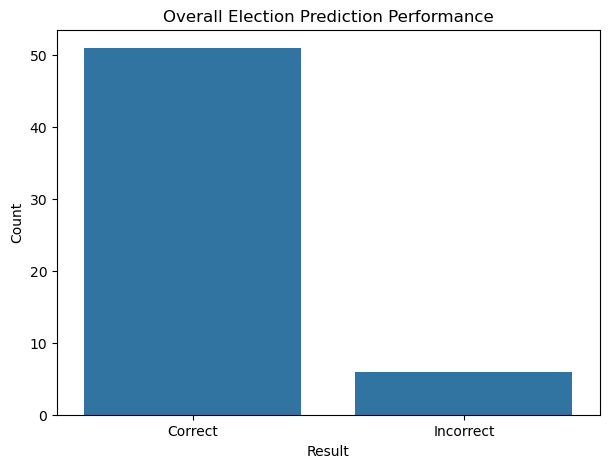

In [94]:
accuracy_data = pd.DataFrame({
    "Result":[
        "Correct",
        "Incorrect"
    ],
    "Count":[
        df["prediction_correct"].sum(),
        (~df["prediction_correct"]).sum()
    ]
})


plt.figure(figsize=(7,5))

sns.barplot(
    data=accuracy_data,
    x="Result",
    y="Count"
)

plt.title(
    "Overall Election Prediction Performance"
)

plt.show()

### Country-Level Accuracy

In [95]:
country_accuracy = (
    df.groupby("Country")
    ["prediction_correct"]
    .mean()
    *100
)


country_accuracy

Country
Brazil            88.888889
Indonesia         80.000000
Portugal         100.000000
South Korea       87.500000
Sri Lanka         77.777778
United States     93.750000
Name: prediction_correct, dtype: float64

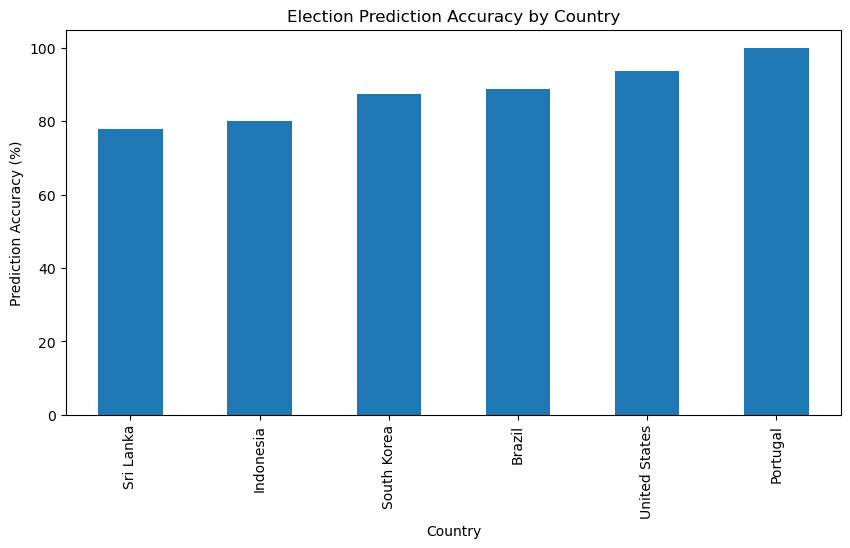

In [96]:
plt.figure(figsize=(10,5))


country_accuracy.sort_values().plot(
    kind="bar"
)


plt.ylabel(
    "Prediction Accuracy (%)"
)

plt.title(
    "Election Prediction Accuracy by Country"
)


plt.show()

### Developed vs Developing Comparison
##### Does development level affect predictability?

In [97]:
development_accuracy = (

    df.groupby("country_type")
    ["prediction_correct"]
    .mean()
    *100

)


development_accuracy

country_type
Developed     94.117647
Developing    82.608696
Name: prediction_correct, dtype: float64

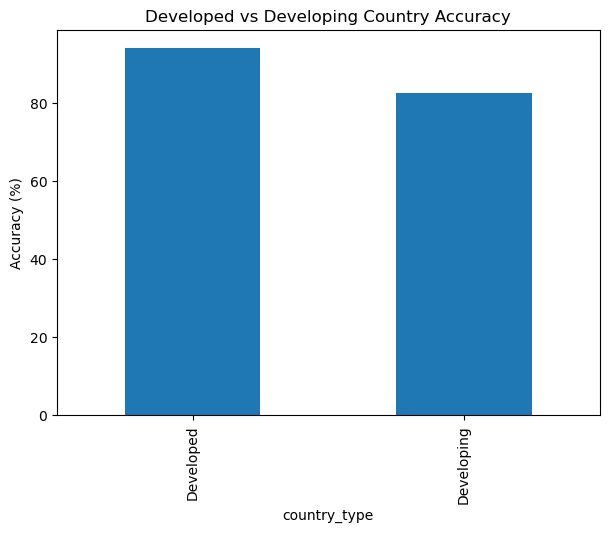

In [98]:
plt.figure(figsize=(7,5))


development_accuracy.plot(
    kind="bar"
)


plt.ylabel(
    "Accuracy (%)"
)


plt.title(
    "Developed vs Developing Country Accuracy"
)


plt.show()

### Agreement Score Analysis
##### Does regional agreement improve prediction?

In [99]:
df[
[
"match_count",
"agreement_score",
"prediction_correct"
]
]

,match_count,agreement_score,prediction_correct
0,3,1.000000,True
1,3,1.000000,True
2,3,1.000000,True
3,2,0.666667,True
4,2,0.666667,True
5,2,0.666667,True
6,2,0.666667,True
7,3,1.000000,True
8,1,0.333333,False
9,2,0.666667,True


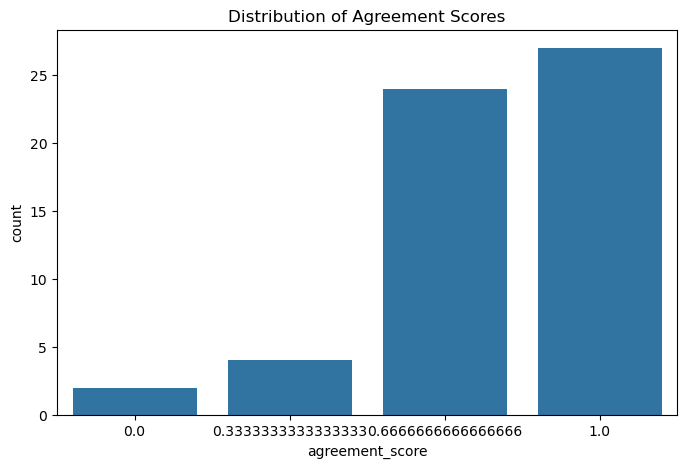

In [100]:
plt.figure(figsize=(8,5))


sns.countplot(
    data=df,
    x="agreement_score"
)


plt.title(
    "Distribution of Agreement Scores"
)


plt.show()

### Agreement Score vs Accuracy

In [101]:
agreement_accuracy = (

df.groupby("agreement_score")
["prediction_correct"]
.mean()
*100

)


agreement_accuracy

agreement_score
0.000000      0.0
0.333333      0.0
0.666667    100.0
1.000000    100.0
Name: prediction_correct, dtype: float64

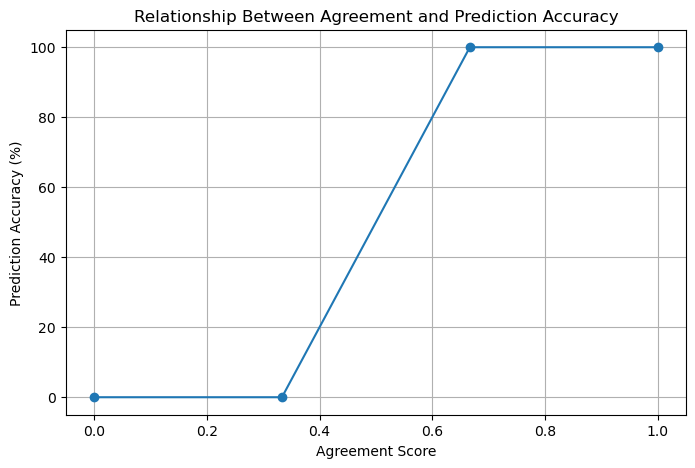

In [102]:
plt.figure(figsize=(8,5))


agreement_accuracy.plot(
    kind="line",
    marker="o"
)


plt.ylabel(
    "Prediction Accuracy (%)"
)


plt.xlabel(
    "Agreement Score"
)


plt.title(
    "Relationship Between Agreement and Prediction Accuracy"
)


plt.grid()

plt.show()

### Historical Trend Analysis
Has predictability changed over time?

In [103]:
year_accuracy = (

df.groupby("election_decade")
["prediction_correct"]
.mean()
*100

)


year_accuracy

election_decade
1960    100.000000
1970    100.000000
1980     88.888889
1990    100.000000
2000    100.000000
2010     85.714286
2020     57.142857
Name: prediction_correct, dtype: float64

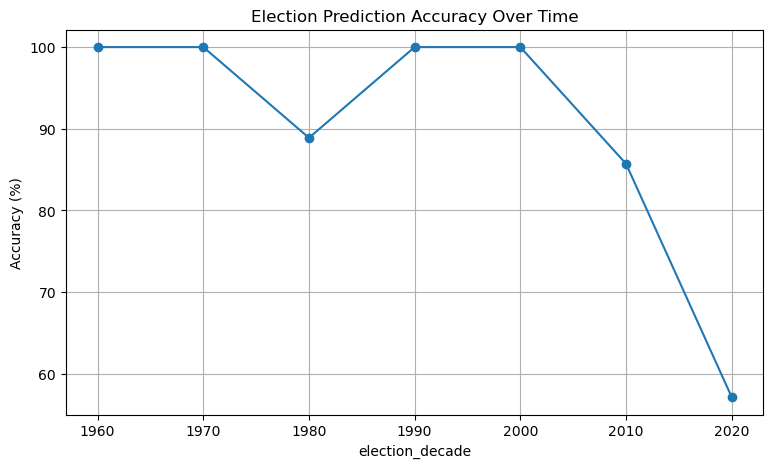

In [104]:
plt.figure(figsize=(9,5))


year_accuracy.plot(
    marker="o"
)


plt.ylabel(
    "Accuracy (%)"
)


plt.title(
    "Election Prediction Accuracy Over Time"
)


plt.grid()

plt.show()

### Top 3 Sweep Analysis
##### How often did one candidate dominate all largest electorates?

In [105]:
sweep_count = (
df["top3_sweep"]
.value_counts()
)


sweep_count

top3_sweep
True     29
False    28
Name: count, dtype: int64

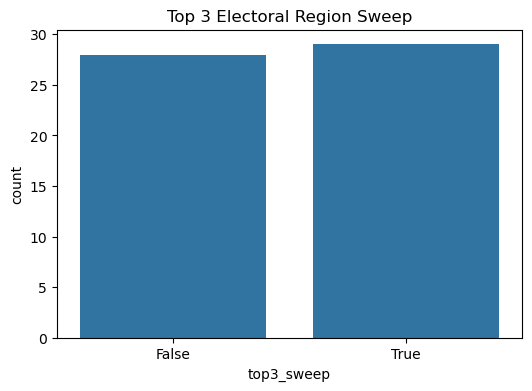

In [106]:
plt.figure(figsize=(6,4))


sns.countplot(
    data=df,
    x="top3_sweep"
)


plt.title(
    "Top 3 Electoral Region Sweep"
)


plt.show()

### Regional Diversity Analysis
##### Do diverse regions make prediction harder?

In [107]:
diversity_analysis = (

df.groupby(
"regional_winner_diversity"
)
["prediction_correct"]
.mean()
*100

)


diversity_analysis

regional_winner_diversity
1    93.103448
2    85.714286
Name: prediction_correct, dtype: float64

### Find Failed Predictions

In [108]:
failed_predictions = df[
    df["prediction_correct"] == False
]


failed_predictions[
[
"Country",
"election_year",
"largest_winner",
"second_winner",
"third_winner",
"national_winner",
"match_count"
]
]

,Country,election_year,largest_winner,second_winner,third_winner,national_winner,match_count
8,Brazil,2022,Jair Bolsonaro,Lula,Jair Bolsonaro,Lula,1
11,Indonesia,2014,Prabowo Subianto,Prabowo Subianto,Joko Widodo,Joko Widodo,1
31,South Korea,2022,Lee Jae-myung,Lee Jae-myung,Yoon Suk Yeol,Yoon Suk Yeol,1
33,Sri Lanka,1988,Sirimavo Bandaranaike,Sirimavo Bandaranaike,Sirimavo Bandaranaike,Ranasinghe Premadasa,0
38,Sri Lanka,2015,Mahinda Rajapaksa,Mahinda Rajapaksa,Mahinda Rajapaksa,Maithripala Sirisena,0
55,United States,2020,Joe Biden,Donald Trump,Donald Trump,Joe Biden,1


### Correlation Analysis

In [109]:
numeric_features = df.select_dtypes(
include=np.number
)


correlation = numeric_features.corr()


correlation

,election_year,match_count,agreement_score,regional_winner_diversity,election_decade,years_since_previous_election,country_total_elections,country_type_encoded,majority_winner_region_count
election_year,1.000000,-0.208363,-0.208363,0.150696,0.983824,0.075911,-0.363393,-0.291010,-0.150696
match_count,-0.208363,1.000000,1.000000,-0.618081,-0.210503,0.026527,0.036772,0.078728,0.618081
agreement_score,-0.208363,1.000000,1.000000,-0.618081,-0.210503,0.026527,0.036772,0.078728,0.618081
regional_winner_diversity,0.150696,-0.618081,-0.618081,1.000000,0.163479,-0.349189,0.086714,0.164395,-1.000000
election_decade,0.983824,-0.210503,-0.210503,0.163479,1.000000,0.051709,-0.326772,-0.246101,-0.163479
years_since_previous_election,0.075911,0.026527,0.026527,-0.349189,0.051709,1.000000,-0.604331,-0.181625,0.349189
country_total_elections,-0.363393,0.036772,0.036772,0.086714,-0.326772,-0.604331,1.000000,0.580062,-0.086714
country_type_encoded,-0.291010,0.078728,0.078728,0.164395,-0.246101,-0.181625,0.580062,1.000000,-0.164395
majority_winner_region_count,-0.150696,0.618081,0.618081,-1.000000,-0.163479,0.349189,-0.086714,-0.164395,1.000000


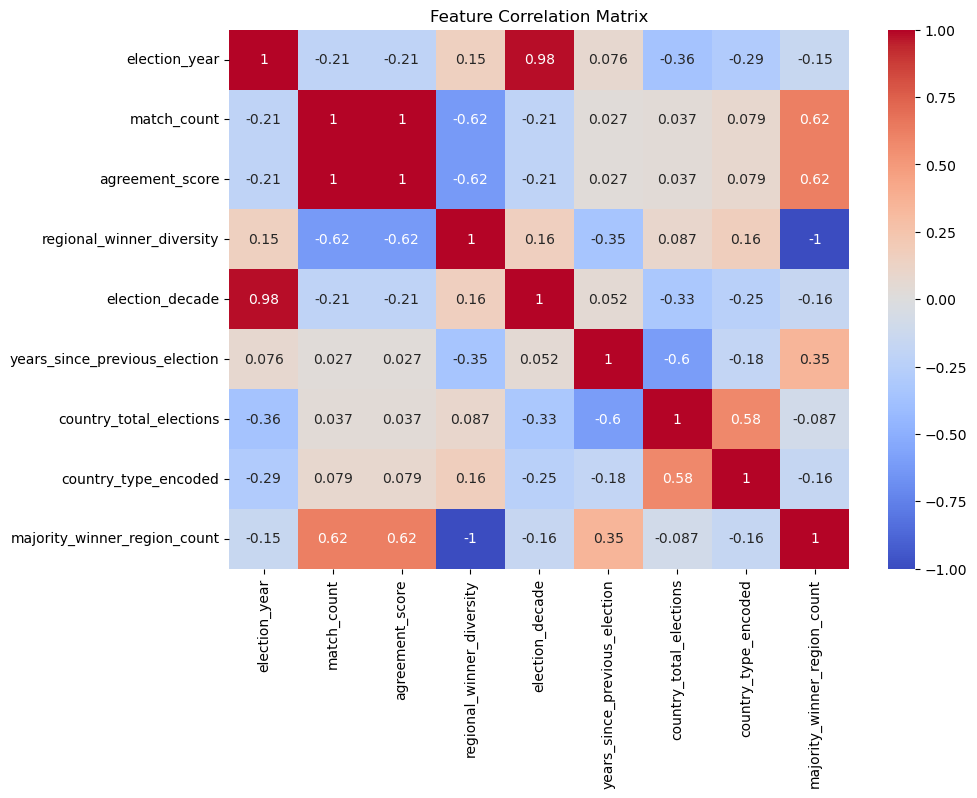

In [110]:
plt.figure(figsize=(10,7))


sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)


plt.title(
"Feature Correlation Matrix"
)


plt.show()

In [111]:
country_accuracy.to_csv(
r"D:\Election Data Project\data\processed\country_accuracy.csv"
)

In [112]:
failed_predictions.to_csv(
r"D:\Election Data Project\data\processed\failed_predictions.csv",
index=False
)